#  LogisticRegression On Imbalanced Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

In [3]:
from collections import Counter
from sklearn.datasets import make_classification

In [6]:
X,Y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)

In [7]:
pd.DataFrame(X)
pd.DataFrame(Y)


,0
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [14]:
pd.DataFrame(X)

,0,1
0,1.879910,-1.485035
1,0.377083,-2.238585
2,1.354312,-2.664638
3,-0.509843,-1.502950
4,0.863561,-1.906364
...,...,...
9995,1.066698,-0.548159
9996,1.058723,-0.933768
9997,0.995099,-0.541924
9998,1.758594,-1.549612


In [8]:
Counter(Y)

Counter({np.int64(0): 9846, np.int64(1): 154})

<Axes: >

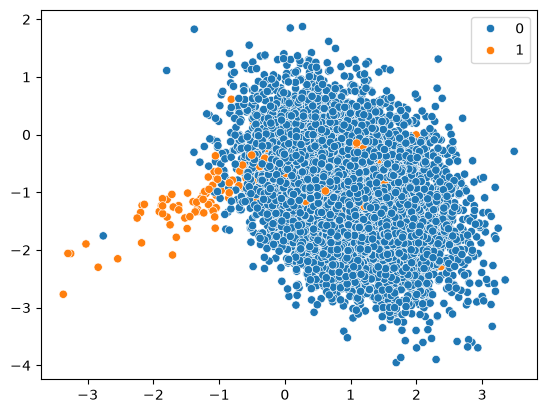

In [12]:
sns.scatterplot(x=X[:,0],y=X[: ,1],hue=Y)

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)


In [18]:
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [19]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [16]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [20]:
penality=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg','lbfgs','liblinear','sag','saga']


In [23]:
params = [
    {
        'penalty': ['l1', 'l2'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'solver': ['liblinear'],
        'class_weight': class_weight
        
    },

    {
        'penalty': ['l2'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'solver': ['newton-cg', 'lbfgs', 'sag'],
        'class_weight': class_weight
    },

    {
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [100, 10, 1.0, 0.1, 0.01],
        'solver': ['saga'],
        'class_weight': class_weight
    }
]


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=1)

In [30]:
grid.fit(X_train,Y_train)
warnings.filterwarnings("ignore")


c:\Users\HP\OneDrive\Desktop\Ridge_Lasso_Elasticnet\rlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\OneDrive\Desktop\Ridge_Lasso_Elasticnet\rlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\HP\OneDrive\Desktop\Ridge_Lasso_Elasticnet\rlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its d

In [31]:
grid.best_score_

np.float64(0.9882666666666667)

In [32]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 50, 1: 100},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [34]:
y_pred=grid.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [36]:
score=accuracy_score(y_pred,Y_test)
print(score)
print(classification_report(y_pred,Y_test))
print(confusion_matrix(y_pred,Y_test))

0.9896
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2491
           1       0.26      1.00      0.41         9

    accuracy                           0.99      2500
   macro avg       0.63      0.99      0.70      2500
weighted avg       1.00      0.99      0.99      2500

[[2465   26]
 [   0    9]]
